===== LOAN APPROVAL PREDICTION =====

===== ORIGINAL DATASET =====
    ApplicantIncome  CoapplicantIncome  LoanAmount  CreditScore  LoanTerm  \
0             50000              20000      150000          750       360   
1             35000              10000      120000          680       360   
2             25000               5000      100000          620       360   
3             70000              25000      200000          780       360   
4             30000                  0       90000          580       360   
5             45000              15000      130000          720       360   
6             20000               5000       80000          550       360   
7             80000              30000      250000          800       360   
8             40000              10000      110000          650       360   
9             28000               5000       95000          590       360   
10            60000              20000      180000          760       360   
11       

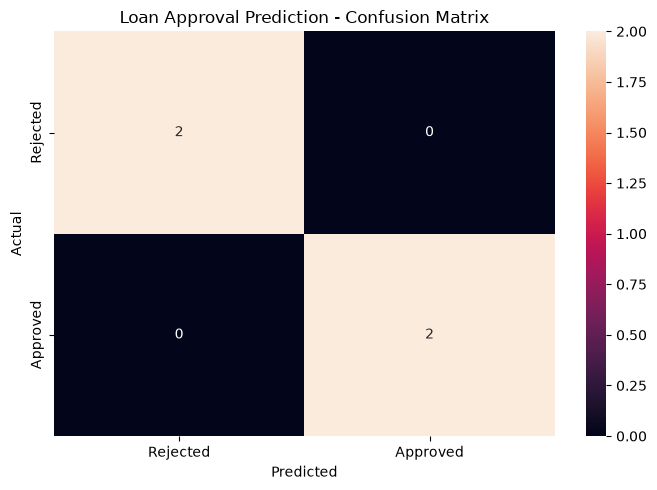


===== METRICS =====
      Metric  Score
0   Accuracy    1.0
1  Precision    1.0
2     Recall    1.0
3   F1 Score    1.0


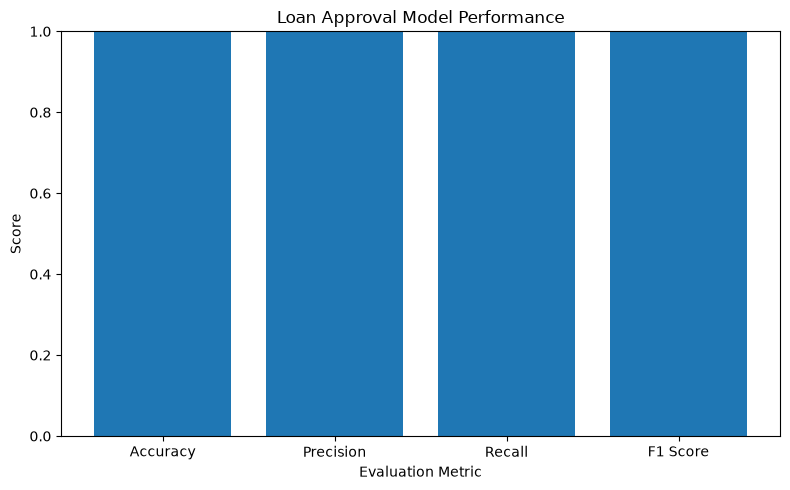


===== NEW LOAN APPLICATION =====
   ApplicantIncome  CoapplicantIncome  LoanAmount  CreditScore  LoanTerm  \
0            55000              15000      140000          720       360   

   PropertyArea  EmploymentStatus  Education  Married  
0             2                 0          0        1  
Predicted Loan Status: APPROVED

===== PROJECT COMPLETED =====
Dataset cleaned and preprocessed.
Logistic Regression model trained.
Predictions generated.
Model evaluated.
Confusion matrix saved as confusion_matrix.png.
Performance chart saved as model_evaluation.png.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

df = pd.read_csv("loan_approval_dataset.csv")

print("===== LOAN APPROVAL PREDICTION =====")

print("\n===== ORIGINAL DATASET =====")
print(df)

print("\n===== DATASET INFORMATION =====")
print(df.info())

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== DUPLICATE RECORDS =====")
print(df.duplicated().sum())

df = df.drop_duplicates()

categorical_columns = [
    "PropertyArea",
    "EmploymentStatus",
    "Education",
    "Married"
]

label_encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()
    df[column] = encoder.fit_transform(df[column])
    label_encoders[column] = encoder

df["LoanApproved"] = df["LoanApproved"].map({"Yes": 1, "No": 0})

print("\n===== PREPROCESSED DATASET =====")
print(df)

X = df.drop("LoanApproved", axis=1)
y = df["LoanApproved"]

print("\n===== FEATURES =====")
print(X.columns.tolist())

print("\n===== TARGET =====")
print("LoanApproved")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("\n===== MODEL PERFORMANCE =====")
print("Accuracy:", round(accuracy * 100, 2), "%")
print("Precision:", round(precision, 2))
print("Recall:", round(recall, 2))
print("F1 Score:", round(f1, 2))

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)

print("\n===== CONFUSION MATRIX =====")
print(cm)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)
plt.title("Loan Approval Prediction - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Score": [accuracy, precision, recall, f1]
})

print("\n===== METRICS =====")
print(metrics.round(3))

plt.figure(figsize=(8, 5))
plt.bar(metrics["Metric"], metrics["Score"])
plt.title("Loan Approval Model Performance")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=300)
plt.show()

new_applicant = pd.DataFrame({
    "ApplicantIncome": [55000],
    "CoapplicantIncome": [15000],
    "LoanAmount": [140000],
    "CreditScore": [720],
    "LoanTerm": [360],
    "PropertyArea": [label_encoders["PropertyArea"].transform(["Urban"])[0]],
    "EmploymentStatus": [label_encoders["EmploymentStatus"].transform(["Employed"])[0]],
    "Education": [label_encoders["Education"].transform(["Graduate"])[0]],
    "Married": [label_encoders["Married"].transform(["Yes"])[0]]
})

prediction = model.predict(new_applicant)[0]

print("\n===== NEW LOAN APPLICATION =====")
print(new_applicant)

if prediction == 1:
    print("Predicted Loan Status: APPROVED")
else:
    print("Predicted Loan Status: REJECTED")

print("\n===== PROJECT COMPLETED =====")
print("Dataset cleaned and preprocessed.")
print("Logistic Regression model trained.")
print("Predictions generated.")
print("Model evaluated.")
print("Confusion matrix saved as confusion_matrix.png.")
print("Performance chart saved as model_evaluation.png.")

# 🏦 Loan Approval Prediction

## Project Overview

This project demonstrates an end-to-end Machine Learning workflow for predicting loan approval.

A small educational loan application dataset was used. The dataset contains applicant income, loan amount, credit score, employment status, education, marital status, property area, and loan term.

The target variable is whether the loan is approved or rejected.

## Machine Learning Workflow

1. Load the dataset
2. Inspect the data
3. Check missing values
4. Check duplicate records
5. Encode categorical variables
6. Separate features and target
7. Split the dataset into training and testing sets
8. Train a Logistic Regression model
9. Generate predictions
10. Evaluate model performance
11. Generate a confusion matrix
12. Test the model with a new applicant

## Model

Logistic Regression was selected because loan approval is a binary classification problem.

The model predicts two possible outcomes:

- Approved
- Rejected

## Evaluation Metrics

The model is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score

A confusion matrix is also generated to examine correct and incorrect predictions.

## Important Note

This dataset is a small educational dataset created for demonstrating an end-to-end Machine Learning workflow. It is not intended for real-world lending decisions.

## 📚 Reference

Scikit-learn Documentation:
https://scikit-learn.org/stable/

Scikit-learn Logistic Regression:
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html